In [1]:
import uproot, glob
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import os, glob, pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import mplhep as hep
plt.style.use([hep.style.ROOT, hep.style.firamath])
from matplotlib.colors import LinearSegmentedColormap
import scipy
from scipy.stats import norm
# Define the CMS color scheme
cms_colors = [
    (0.00, '#FFFFFF'),  # White
    (0.33, '#005EB8'),  # Blue
    (0.66, '#FFDD00'),  # Yellow
    (1.00, '#FF0000')   # red
]

# Create the CMS colormap
cms_cmap = LinearSegmentedColormap.from_list('CMS', cms_colors)

mkdir -p failed for path /uscms_data/d1/bbbam/.cache/matplotlib: [Errno 30] Read-only file system: '/uscms_data'
Matplotlib created a temporary cache directory at /tmp/matplotlib-ccg6pf1q because there was an issue with the default path (/uscms_data/d1/bbbam/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# out_dir='data/plot_H_AA_4Tau_M_10_signal_kinematics'
# out_dir='../analysis_run3/AN_Note_Plot/mass_regression_with_map_signal_background_pridiction'
out_dir='../analysis_run3/AN_Note_Plot/stack_plots'
if not os.path.isdir(out_dir):
    os.makedirs(out_dir)


(exptext: Custom Text(0.0, 1, 'CMS'),
 expsuffix: Custom Text(0.0, 1.005, 'Simulation'),
 supptext: Custom Text(1.012, 1, ''))

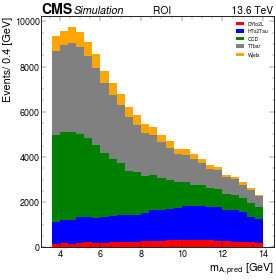

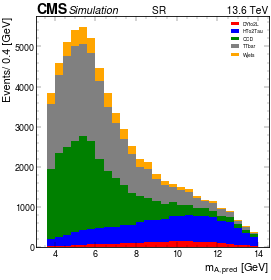

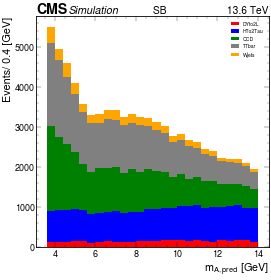

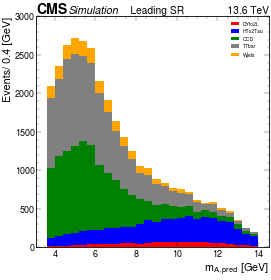

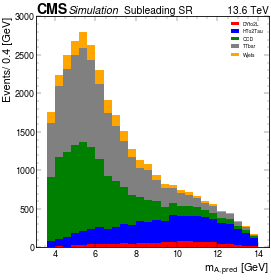

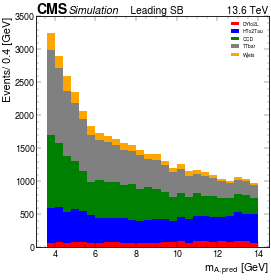

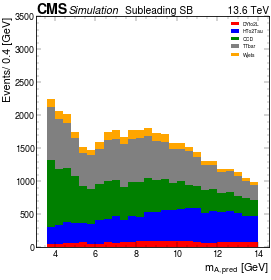

In [5]:
def corrected_pred_mode_miniAOD_5(m):
    mass = m + 0.007372 * m**3 - 0.1353 * m**2 + 0.6927 * m - 2.9
    return mass

# data_files_back = ['QCD_background_11.h5.pkl', 'DYto2L_background_1.h5.pkl',       
#    'HTo2Tau_background_2.h5.pkl',    'TTBar_background_12.h5.pkl', 'WtoLNu_background_1.h5.pkl']

# data_dir ='../analysis_run3/Data_for_plots/ResNet_mapA_signal_backgrounds/'

# back = ['QCD', 'DYTo2Tau', 'HTo2Tau', 'TTBar', 'WToLNu']



sig = ['3.7 GeV', '4 GeV', '5 GeV', '6 GeV', '8 GeV', '10 GeV', '12 GeV', '14 GeV']
back = ["DYto2L", "HTo2Tau", "QCD", "TTbar", "Wjets"]
col_ = ['red','blue','green','grey', 'orange']



data_dir = "../analysis_run3/Data_for_plots/ResNet_mapA_signal_backgrounds_5_ch_inference_miniAOD"


# sig_back = ["3.7 GeV", "4 GeV", "5 GeV", "6 GeV", "8 GeV", "10 GeV", "12 GeV", "14 GeV", "DYto2L", "HTo2Tau", "QCD", "TTbar", "Wjets"]
m_true_mass = [3.7, 4, 5, 6, 8, 10, 12, 14]
data_files_signal = [
    "IMG_signal_mass_3p7_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_4_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_5_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_6_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_8_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_10_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_12_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_14_GeV_miniAOD_combined.pkl",
]

data_files_back = [ "IMG_background_DYto2L_miniAOD_combined.pkl",
    "IMG_background_HTo2Tau_miniAOD_combined.pkl",
    "IMG_background_QCD_miniAOD_combined.pkl",
    "IMG_background_TTbar_miniAOD_combined.pkl",
    "IMG_background_Wjets_miniAOD_combined.pkl",
]


m0_min=3.6
m0_max=14.1
bin_size =0.4
bins = np.arange(m0_min,m0_max,bin_size)

total_background, total_weight = [], []
total_background_sr, total_weight_sr_total = [], []
total_background_sb, total_weight_sb_total = [], []
total_background_leading_sr, total_background_subleading_sr, total_weight_sr = [], [], []
total_background_leading_sb, total_background_subleading_sb, total_weight_sb = [], [], []

for i, file_ in enumerate(data_files_back):

    data_file = f"{data_dir}/{file_}"

    with open(data_file, "rb") as infile:
        data = pickle.load(infile)

    m_pred_total = corrected_pred_mode_miniAOD_5(
        data["m_pred"]
    ).flatten()

    jet_pt_total = data["jet_pt"].flatten()

    # ---------------------------------------------------------
    # Make even number of jets
    # ---------------------------------------------------------
    n = len(m_pred_total)
    n_even = n #- (n % 2)

    # reshape into jet pairs (events)
    m_pred = m_pred_total[:n_even].reshape(-1, 2)
    jet_pt = jet_pt_total[:n_even].reshape(-1, 2)

    # ---------------------------------------------------------
    # Leading / subleading jet indices
    # ---------------------------------------------------------
    lead_idx = np.argmax(jet_pt, axis=1)
    sublead_idx = 1 - lead_idx

    # corresponding masses
    m_leading = m_pred[np.arange(len(m_pred)), lead_idx]
    m_subleading = m_pred[np.arange(len(m_pred)), sublead_idx]

    # corresponding pts
    pt_leading = jet_pt[np.arange(len(jet_pt)), lead_idx]
    pt_subleading = jet_pt[np.arange(len(jet_pt)), sublead_idx]

    # ---------------------------------------------------------
    # Event-level mass selection:
    # BOTH jets must satisfy the mass window
    # ---------------------------------------------------------
    mask_pair = (
        (m_leading >= 3.6) &
        (m_leading <= 14) &
        (m_subleading >= 3.6) &
        (m_subleading <= 14)
    )

    m_leading = m_leading[mask_pair]
    m_subleading = m_subleading[mask_pair]

    # ---------------------------------------------------------
    # Save total selected jets
    # ---------------------------------------------------------
    total_background.append(
        np.concatenate([m_leading, m_subleading])
    )

    weights = np.ones(len(m_leading) * 2)
    total_weight.append(weights)

    # ---------------------------------------------------------
    # Signal region
    # ---------------------------------------------------------
    sr_mask = np.abs(m_leading - m_subleading) <= 2

    m_leading_sr = m_leading[sr_mask]
    m_subleading_sr = m_subleading[sr_mask]

    weights_sr = np.ones_like(m_leading_sr)

    total_background_leading_sr.append(m_leading_sr)
    total_background_subleading_sr.append(m_subleading_sr)
    total_weight_sr.append(weights_sr)

    total_background_sr.append(
        np.concatenate([m_leading_sr, m_subleading_sr])
    )

    weights_sr_total = np.ones(len(m_leading_sr) * 2)
    total_weight_sr_total.append(weights_sr_total)

    
    # ---------------------------------------------------------
    # Sideband region
    # ---------------------------------------------------------
    sb_mask = np.abs(m_leading - m_subleading) > 2

    m_leading_sb = m_leading[sb_mask]
    m_subleading_sb = m_subleading[sb_mask]

    weights_sb = np.ones_like(m_leading_sb)

    total_background_leading_sb.append(m_leading_sb)
    total_background_subleading_sb.append(m_subleading_sb)
    total_weight_sb.append(weights_sb)

    total_background_sb.append(
        np.concatenate([m_leading_sb, m_subleading_sb])
    )

    weights_sb_total = np.ones(len(m_leading_sb) * 2)
    total_weight_sb_total.append(weights_sb_total)


dpi_=30

# =========================================================
# Stack histogram
# =========================================================

fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background,
    bins=bins,
    weights=total_weight,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    # edgecolor="black",
    linewidth=0.8,
)

plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')
plt.legend(loc='upper right', fontsize=12)
hep.cms.label(llabel="Simulation", rlabel=f" ROI                     13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_ROI.pdf', bbox_inches='tight',dpi=300, facecolor = "w")


fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_sr,
    bins=bins,
    weights=total_weight_sr_total,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    # edgecolor="black",
    linewidth=0.8,
)

plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')
plt.legend(loc='upper right', fontsize=12)
hep.cms.label(llabel="Simulation", rlabel=f" SR                     13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_SR.pdf', bbox_inches='tight',dpi=300, facecolor = "w")


fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_sb,
    bins=bins,
    weights=total_weight_sb_total,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    # edgecolor="black",
    linewidth=0.8,
)

plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')
plt.legend(loc='upper right', fontsize=12)
hep.cms.label(llabel="Simulation", rlabel=f" SB                     13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_SB.pdf', bbox_inches='tight',dpi=300, facecolor = "w")




fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_leading_sr,
    bins=bins,
    weights=total_weight_sr,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    # edgecolor="black",
    linewidth=0.8,
)
plt.ylim(0,3000)
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')
plt.legend(loc='upper right', fontsize=12)
hep.cms.label(llabel="Simulation", rlabel=f"     Leading SR               13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_leading_SR.pdf', bbox_inches='tight',dpi=300, facecolor = "w")


fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_subleading_sr,
    bins=bins,
    weights=total_weight_sr,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    # edgecolor="black",
    linewidth=0.8,
)
plt.ylim(0,3000)
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')
plt.legend(loc='upper right', fontsize=12)
hep.cms.label(llabel="Simulation", rlabel=f"        Subleading SR            13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_subleading_SR.pdf', bbox_inches='tight',dpi=300, facecolor = "w")




fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_leading_sb,
    bins=bins,
    weights=total_weight_sb,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    # edgecolor="black",
    linewidth=0.8,
)
plt.ylim(0,3500)
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')
plt.legend(loc='upper right', fontsize=12)
hep.cms.label(llabel="Simulation", rlabel=f"     Leading SB               13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_leading_SB.pdf', bbox_inches='tight',dpi=300, facecolor = "w")


fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_subleading_sb,
    bins=bins,
    weights=total_weight_sb,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    # edgecolor="black",
    linewidth=0.8,
)
plt.ylim(0,3500)
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')
plt.legend(loc='upper right', fontsize=12)
hep.cms.label(llabel="Simulation", rlabel=f"        Subleading SB            13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_subleading_SB.pdf', bbox_inches='tight',dpi=300, facecolor = "w")